# BBC Articles Two-Stage Classification: Sport / Non-Sport -> Individual Sport

Hierarchical classification pipeline

how it works:

- Read ds
- Remove generic `/sport/articles/...` pages because they are not a single sport
- Stage 1: classify each article as `sport` or `non-sport`
- Stage 2: only for articles predicted as `sport`, classify the specific sport
- unify title + text = combined_text
- use train/validation/test splits for both stages

TEXT VECTORIZATION

it doesnt use the text as string BUT it converts it in numbers.

- lowercase, without accents, REMOVE 'the/and/is...'
- ngram_range=(1,2) -> single and couple worlds 'premier league, grand slam, rugby world cup...'
- makes common worls across every article weight less ('the/is...')
- makes topic-specific worlds weight MORE ('goal', 'wicket', 'serve', 'scrum', 'stock market'...)

PIPELINE IDEA:

- first model decides if the article is about sport at all
- second model specializes only on sport articles and predicts the single sport
- if stage 1 says `non-sport`, the pipeline stops there


## 1. Setup

In [55]:
# !pip install pandas scikit-learn matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from urllib.parse import urlparse

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load and view ds

In [56]:
DATA_PATH = 'bbc_articles.csv'

df = pd.read_csv(DATA_PATH, sep=';')

print(f'Dataset shape: {df.shape}')
display(df.head(3))
print('\nOriginal category distribution:')
print(df['category'].value_counts())


Dataset shape: (2000, 4)


,title,text,category,url
0,Norwich's Sargent completes move to Toronto,Josh Sargent scored 56 goals in 157 appearance...,sport,https://www.bbc.com/sport/football/articles/c9...
1,Arsenal's Smith out of Canada squad with concu...,Olivia Smith started Arsenal's FA Cup fifth-ro...,sport,https://www.bbc.com/sport/football/articles/cd...
2,Gordon needs to stay 'fully focused' after Ars...,Anthony Gordon has scored 14 goals for Newcast...,sport,https://www.bbc.com/sport/football/articles/cn...



Original category distribution:
category
sport        1000
non-sport    1000
Name: count, dtype: int64


## 3. Targets and text preparation

In [57]:
def extract_sport_label(url):
    parts = [part for part in urlparse(url).path.split('/') if part]
    if len(parts) >= 2 and parts[0] == 'sport':
        return parts[1]
    return np.nan


df = df[df['category'].isin(['sport', 'non-sport'])].copy()
df['title'] = df['title'].fillna('')
df['text'] = df['text'].fillna('')
df['combined_text'] = (df['title'] + ' ' + df['text']).str.strip()

df['sport_label'] = np.where(
    df['category'] == 'sport',
    df['url'].apply(extract_sport_label),
    'non-sport'
)

# remove generic BBC sport landing pages because they are not a single sport class
df = df[df['sport_label'].notna()].copy()
df = df[df['sport_label'] != 'articles'].copy()

df['binary_label'] = df['category'].map({'non-sport': 0, 'sport': 1})
df['final_label'] = np.where(df['category'] == 'sport', df['sport_label'], 'non-sport')

sport_class_counts = df[df['category'] == 'sport']['sport_label'].value_counts().sort_values(ascending=False)

print(f'Rows kept after cleanup: {len(df)}')
print('\nBinary distribution:')
print(df['category'].value_counts())
print('\nSport distribution:')
print(sport_class_counts)
print('\nEmpty combined_text rows:', (df['combined_text'].str.len() == 0).sum())


Rows kept after cleanup: 1967

Binary distribution:
category
non-sport    1000
sport         967
Name: count, dtype: int64

Sport distribution:
sport_label
football              275
cricket               208
formula1               91
rugby-union            86
tennis                 84
boxing                 70
athletics              52
golf                   38
cycling                30
netball                11
olympics                5
rugby-league            5
ice-hockey              4
snooker                 4
mixed-martial-arts      2
swimming                1
motorsport              1
Name: count, dtype: int64

Empty combined_text rows: 0


## 4. Train / Validation / Test Split

In [58]:
def split_single_class(group, random_state=RANDOM_STATE):
    shuffled = group.sample(frac=1, random_state=random_state)
    n = len(shuffled)

    if n == 1:
        train_n, val_n, test_n = 1, 0, 0
    elif n == 2:
        train_n, val_n, test_n = 1, 0, 1
    elif n == 3:
        train_n, val_n, test_n = 1, 1, 1
    elif n == 4:
        train_n, val_n, test_n = 2, 1, 1
    else:
        val_n = max(1, int(round(n * 0.20)))
        test_n = max(1, int(round(n * 0.20)))
        train_n = n - val_n - test_n

        if train_n < 1:
            train_n = 1
            if val_n >= test_n and val_n > 1:
                val_n -= 1
            else:
                test_n -= 1

    train_split = shuffled.iloc[:train_n]
    val_split = shuffled.iloc[train_n:train_n + val_n]
    test_split = shuffled.iloc[train_n + val_n:train_n + val_n + test_n]

    return train_split, val_split, test_split


# split non-sport with a standard stratified split
non_sport_df = df[df['category'] == 'non-sport'].copy()
ns_train_val, ns_test = train_test_split(
    non_sport_df,
    test_size=0.20,
    random_state=RANDOM_STATE
)
ns_train, ns_val = train_test_split(
    ns_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE
)

# split sport per single sport so every discovered sport stays in training
sport_df = df[df['category'] == 'sport'].copy()
sport_train_parts = []
sport_val_parts = []
sport_test_parts = []

for _, group in sport_df.groupby('sport_label', sort=False):
    train_part, val_part, test_part = split_single_class(group)
    sport_train_parts.append(train_part)
    if len(val_part) > 0:
        sport_val_parts.append(val_part)
    if len(test_part) > 0:
        sport_test_parts.append(test_part)

sport_train_df = pd.concat(sport_train_parts)
sport_val_df = pd.concat(sport_val_parts)
sport_test_df = pd.concat(sport_test_parts)

# final splits used by stage 1 (binary)
train_df = pd.concat([ns_train, sport_train_df]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
val_df = pd.concat([ns_val, sport_val_df]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
test_df = pd.concat([ns_test, sport_test_df]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f'Train size: {len(train_df)}')
print(f'Validation size: {len(val_df)}')
print(f'Test size: {len(test_df)}')

print('\nTrain binary balance:')
print(train_df['category'].value_counts())
print('\nValidation binary balance:')
print(val_df['category'].value_counts())
print('\nTest binary balance:')
print(test_df['category'].value_counts())

print('\nTrain sport balance:')
print(sport_train_df['sport_label'].value_counts())
print('\nValidation sport balance:')
print(sport_val_df['sport_label'].value_counts())
print('\nTest sport balance:')
print(sport_test_df['sport_label'].value_counts())


Train size: 1180
Validation size: 393
Test size: 394

Train binary balance:
category
non-sport    600
sport        580
Name: count, dtype: int64

Validation binary balance:
category
non-sport    200
sport        193
Name: count, dtype: int64

Test binary balance:
category
non-sport    200
sport        194
Name: count, dtype: int64

Train sport balance:
sport_label
football              165
cricket               124
formula1               55
rugby-union            52
tennis                 50
boxing                 42
athletics              32
golf                   22
cycling                18
netball                 7
olympics                3
rugby-league            3
ice-hockey              2
snooker                 2
swimming                1
mixed-martial-arts      1
motorsport              1
Name: count, dtype: int64

Validation sport balance:
sport_label
football        55
cricket         42
formula1        18
tennis          17
rugby-union     17
boxing          14
athletics   

## 5. Stage 1: Sport vs Non-Sport

In [59]:
X_train_bin = train_df['combined_text']
y_train_bin = train_df['binary_label']

X_val_bin = val_df['combined_text']
y_val_bin = val_df['binary_label']

X_test_bin = test_df['combined_text']
y_test_bin = test_df['binary_label']

### Option A: TF-IDF

In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer

binary_vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents='unicode',
    stop_words='english',
    ngram_range=(1, 2),
    max_features=30000,
    min_df=2
)

X_train_bin_vec = binary_vectorizer.fit_transform(X_train_bin)
X_val_bin_vec   = binary_vectorizer.transform(X_val_bin)
X_test_bin_vec  = binary_vectorizer.transform(X_test_bin)

VECTORIZER_TYPE = 'TF-IDF'
print(f'[{VECTORIZER_TYPE}] Train shape: {X_train_bin_vec.shape}')
print(f'[{VECTORIZER_TYPE}] Val   shape: {X_val_bin_vec.shape}')
print(f'[{VECTORIZER_TYPE}] Test  shape: {X_test_bin_vec.shape}')

[TF-IDF] Train shape: (1180, 30000)
[TF-IDF] Val   shape: (393, 30000)
[TF-IDF] Test  shape: (394, 30000)


### Option B: Word2Vec

In [73]:
import re
import numpy as np
import gensim.downloader as gensim_api
from nltk.corpus import stopwords

_stop_en = set(stopwords.words('english'))

def _tokenize(text: str) -> list[str]:
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return [t for t in text.split() if t not in _stop_en and len(t) > 1]

def _docs_to_matrix_pooling(texts, model, vector_size: int) -> np.ndarray:
    rows = []
    for text in texts:
        tokens = _tokenize(text)
        vecs = [model[t] for t in tokens if t in model]
        if vecs:
            vecs_arr = np.array(vecs)
            mean_vec = np.mean(vecs_arr, axis=0)
            max_vec  = np.max(vecs_arr,  axis=0)
            std_vec  = np.std(vecs_arr,  axis=0)  # dispersione tra i token
            rows.append(np.concatenate([mean_vec, max_vec, std_vec]))
        else:
            rows.append(np.zeros(vector_size * 3))
    return np.array(rows)

print('Loading Word2Vec model...')
ft_model = gensim_api.load('word2vec-google-news-300')
W2V_VECTOR_SIZE = 300

X_train_bin_vec = _docs_to_matrix_pooling(X_train_bin, ft_model, W2V_VECTOR_SIZE)
X_val_bin_vec   = _docs_to_matrix_pooling(X_val_bin,   ft_model, W2V_VECTOR_SIZE)
X_test_bin_vec  = _docs_to_matrix_pooling(X_test_bin,  ft_model, W2V_VECTOR_SIZE)

VECTORIZER_TYPE = 'Word2Vec pretrained (300d) — mean+max+std'
print(f'[{VECTORIZER_TYPE}] Train shape: {X_train_bin_vec.shape}')  # (n, 900)
print(f'[{VECTORIZER_TYPE}] Val   shape: {X_val_bin_vec.shape}')
print(f'[{VECTORIZER_TYPE}] Test  shape: {X_test_bin_vec.shape}')

Loading Word2Vec model...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
[Word2Vec pretrained (300d) — mean+max+std] Train shape: (1180, 900)
[Word2Vec pretrained (300d) — mean+max+std] Val   shape: (393, 900)
[Word2Vec pretrained (300d) — mean+max+std] Test  shape: (394, 900)


In [74]:
binary_mlp = MLPClassifier(
    hidden_layer_sizes=(256, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=1,
    warm_start=True,
    random_state=RANDOM_STATE
)

EPOCHS = 20
binary_train_acc_history = []
binary_val_acc_history = []

for epoch in range(EPOCHS):
    binary_mlp.fit(X_train_bin_vec, y_train_bin)

    train_pred = binary_mlp.predict(X_train_bin_vec)
    val_pred = binary_mlp.predict(X_val_bin_vec)

    train_acc = accuracy_score(y_train_bin, train_pred)
    val_acc = accuracy_score(y_val_bin, val_pred)

    binary_train_acc_history.append(train_acc)
    binary_val_acc_history.append(val_acc)

print(f'[{VECTORIZER_TYPE}] Stage 1 - Epoch {epoch+1:02d}/{EPOCHS} '
          f'- Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}')


C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\nicho\AppData

[Word2Vec pretrained (300d) — mean+max+std] Stage 1 - Epoch 20/20 - Train Acc: 0.9568 - Val Acc: 0.9262


C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Best stage 1 validation accuracy: 0.9262 at epoch 8


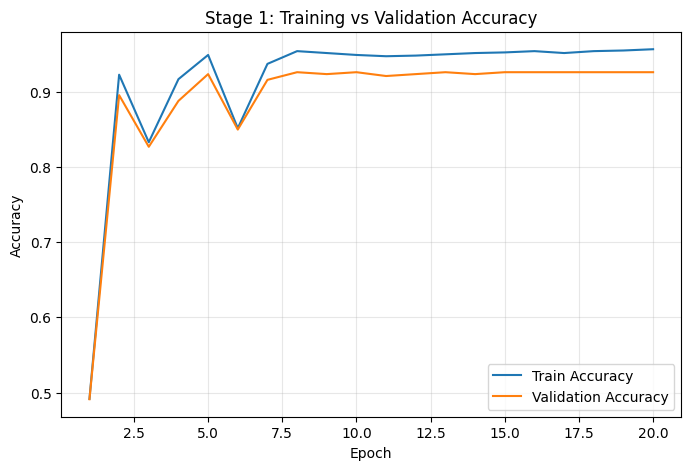

In [75]:
best_binary_epoch = int(np.argmax(binary_val_acc_history))
best_binary_val_acc = binary_val_acc_history[best_binary_epoch]

print(f'Best stage 1 validation accuracy: {best_binary_val_acc:.4f} at epoch {best_binary_epoch + 1}')

plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), binary_train_acc_history, label='Train Accuracy')
plt.plot(range(1, EPOCHS + 1), binary_val_acc_history, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Stage 1: Training vs Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Stage 1 Test Accuracy : 0.9442
Stage 1 Test Precision: 0.9778
Stage 1 Test Recall   : 0.9072
Stage 1 Test F1-score : 0.9412
[Word2Vec pretrained (300d) — mean+max+std] Stage 1

Detailed classification report:

              precision    recall  f1-score   support

   Non-Sport       0.92      0.98      0.95       200
       Sport       0.98      0.91      0.94       194

    accuracy                           0.94       394
   macro avg       0.95      0.94      0.94       394
weighted avg       0.95      0.94      0.94       394



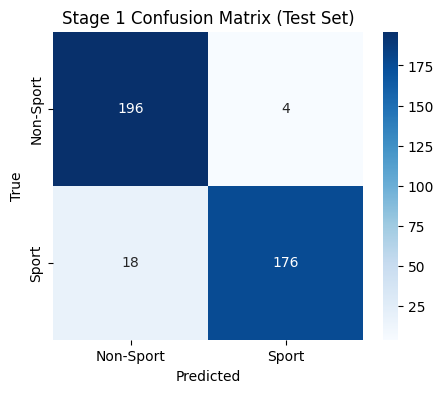

In [76]:
y_test_bin_pred = binary_mlp.predict(X_test_bin_vec)

test_acc = accuracy_score(y_test_bin, y_test_bin_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test_bin,
    y_test_bin_pred,
    average='binary',
    zero_division=0
)

print(f'Stage 1 Test Accuracy : {test_acc:.4f}')
print(f'Stage 1 Test Precision: {precision:.4f}')
print(f'Stage 1 Test Recall   : {recall:.4f}')
print(f'Stage 1 Test F1-score : {f1:.4f}')

print("=============================================================")
print(f'[{VECTORIZER_TYPE}] Stage 1')
print('\nDetailed classification report:')
print()
print(classification_report(y_test_bin, y_test_bin_pred, target_names=['Non-Sport', 'Sport'], zero_division=0))

cm = confusion_matrix(y_test_bin, y_test_bin_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Sport', 'Sport'],
    yticklabels=['Non-Sport', 'Sport']
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Stage 1 Confusion Matrix (Test Set)')
plt.show()


## 6. Stage 2: Individual Sport Classification

In [77]:
# List of sport classes
selected_sports = ["football", "cricket", "tennis", "rugby", "golf", "boxing", "athletics", "cycling", "formula1"]

# print the frequency of each sport class
sport_class_counts = sport_df['sport_label'].value_counts().sort_values(ascending=False)
print(sport_class_counts)

sport_label
football              275
cricket               208
formula1               91
rugby-union            86
tennis                 84
boxing                 70
athletics              52
golf                   38
cycling                30
netball                11
olympics                5
rugby-league            5
ice-hockey              4
snooker                 4
mixed-martial-arts      2
swimming                1
motorsport              1
Name: count, dtype: int64


In [78]:

sport_train_df = sport_train_df[sport_train_df['sport_label'].isin(selected_sports)].copy()
sport_val_df = sport_val_df[sport_val_df['sport_label'].isin(selected_sports)].copy()
sport_test_df = sport_test_df[sport_test_df['sport_label'].isin(selected_sports)].copy()

sport_class_names = sorted(selected_sports)
sport_label_to_id = {label: idx for idx, label in enumerate(sport_class_names)}
sport_id_to_label = {idx: label for label, idx in sport_label_to_id.items()}

sport_train_df['sport_id'] = sport_train_df['sport_label'].map(sport_label_to_id)
sport_val_df['sport_id'] = sport_val_df['sport_label'].map(sport_label_to_id)
sport_test_df['sport_id'] = sport_test_df['sport_label'].map(sport_label_to_id)

X_train_sport = sport_train_df['combined_text']
y_train_sport = sport_train_df['sport_id']

X_val_sport = sport_val_df['combined_text']
y_val_sport = sport_val_df['sport_id']

X_test_sport = sport_test_df['combined_text']
y_test_sport = sport_test_df['sport_id']

In [79]:
#  OPTION A: TF-IDF 
sport_vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents='unicode',
    stop_words='english',
    ngram_range=(1, 2),
    max_features=30000,
    min_df=2
)

X_train_sport_vec = sport_vectorizer.fit_transform(X_train_sport)
X_val_sport_vec   = sport_vectorizer.transform(X_val_sport)
X_test_sport_vec  = sport_vectorizer.transform(X_test_sport)

SPORT_VECTORIZER_TYPE = 'TF-IDF'
print(f'[{SPORT_VECTORIZER_TYPE}] Train shape: {X_train_sport_vec.shape}')
print(f'[{SPORT_VECTORIZER_TYPE}] Val   shape: {X_val_sport_vec.shape}')
print(f'[{SPORT_VECTORIZER_TYPE}] Test  shape: {X_test_sport_vec.shape}')

[TF-IDF] Train shape: (508, 30000)
[TF-IDF] Val   shape: (170, 30000)
[TF-IDF] Test  shape: (170, 30000)


In [80]:
# OPTION B: Word2Vec 

X_train_sport_vec = _docs_to_matrix_pooling(X_train_sport, ft_model, W2V_VECTOR_SIZE)
X_val_sport_vec = _docs_to_matrix_pooling(X_val_sport,   ft_model, W2V_VECTOR_SIZE)
X_test_sport_vec = _docs_to_matrix_pooling(X_test_sport,  ft_model, W2V_VECTOR_SIZE)

SPORT_VECTORIZER_TYPE = 'fastText pretrained (300d)'
print(f'[{SPORT_VECTORIZER_TYPE}] Train shape: {X_train_sport_vec.shape}')
print(f'[{SPORT_VECTORIZER_TYPE}] Val   shape: {X_val_sport_vec.shape}')
print(f'[{SPORT_VECTORIZER_TYPE}] Test  shape: {X_test_sport_vec.shape}')

[fastText pretrained (300d)] Train shape: (508, 900)
[fastText pretrained (300d)] Val   shape: (170, 900)
[fastText pretrained (300d)] Test  shape: (170, 900)


In [81]:
sport_mlp = MLPClassifier(
    hidden_layer_sizes=(256, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=1,
    warm_start=True,
    random_state=RANDOM_STATE
)

sport_train_acc_history = []
sport_val_acc_history = []

print("=============================================================")
print(f'[{SPORT_VECTORIZER_TYPE}] Starting Stage 2 training...')

for epoch in range(EPOCHS):
    sport_mlp.fit(X_train_sport_vec, y_train_sport)

    train_pred = sport_mlp.predict(X_train_sport_vec)
    val_pred = sport_mlp.predict(X_val_sport_vec)

    train_acc = accuracy_score(y_train_sport, train_pred)
    val_acc = accuracy_score(y_val_sport, val_pred)

    sport_train_acc_history.append(train_acc)
    sport_val_acc_history.append(val_acc)

    print(f'Stage 2 - Epoch {epoch + 1:02d}/{EPOCHS} - Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}')



[fastText pretrained (300d)] Starting Stage 2 training...
Stage 2 - Epoch 01/20 - Train Acc: 0.3248 - Val Acc: 0.3235
Stage 2 - Epoch 02/20 - Train Acc: 0.4134 - Val Acc: 0.4176
Stage 2 - Epoch 03/20 - Train Acc: 0.4173 - Val Acc: 0.4294
Stage 2 - Epoch 04/20 - Train Acc: 0.3622 - Val Acc: 0.3941
Stage 2 - Epoch 05/20 - Train Acc: 0.5177 - Val Acc: 0.5294
Stage 2 - Epoch 06/20 - Train Acc: 0.4272 - Val Acc: 0.4529
Stage 2 - Epoch 07/20 - Train Acc: 0.5098 - Val Acc: 0.5294
Stage 2 - Epoch 08/20 - Train Acc: 0.4646 - Val Acc: 0.4824


C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\nicho\AppData

Stage 2 - Epoch 09/20 - Train Acc: 0.6319 - Val Acc: 0.6294
Stage 2 - Epoch 10/20 - Train Acc: 0.4941 - Val Acc: 0.5118
Stage 2 - Epoch 11/20 - Train Acc: 0.5315 - Val Acc: 0.5471
Stage 2 - Epoch 12/20 - Train Acc: 0.5098 - Val Acc: 0.5294
Stage 2 - Epoch 13/20 - Train Acc: 0.5059 - Val Acc: 0.5353
Stage 2 - Epoch 14/20 - Train Acc: 0.4882 - Val Acc: 0.5118
Stage 2 - Epoch 15/20 - Train Acc: 0.5433 - Val Acc: 0.5471


C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\nicho\AppData

Stage 2 - Epoch 16/20 - Train Acc: 0.5571 - Val Acc: 0.5529
Stage 2 - Epoch 17/20 - Train Acc: 0.6122 - Val Acc: 0.5824
Stage 2 - Epoch 18/20 - Train Acc: 0.6949 - Val Acc: 0.6941
Stage 2 - Epoch 19/20 - Train Acc: 0.7697 - Val Acc: 0.7588
Stage 2 - Epoch 20/20 - Train Acc: 0.8012 - Val Acc: 0.7706


C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\nicho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\nicho\AppData

Best stage 2 validation accuracy: 0.7706 at epoch 20


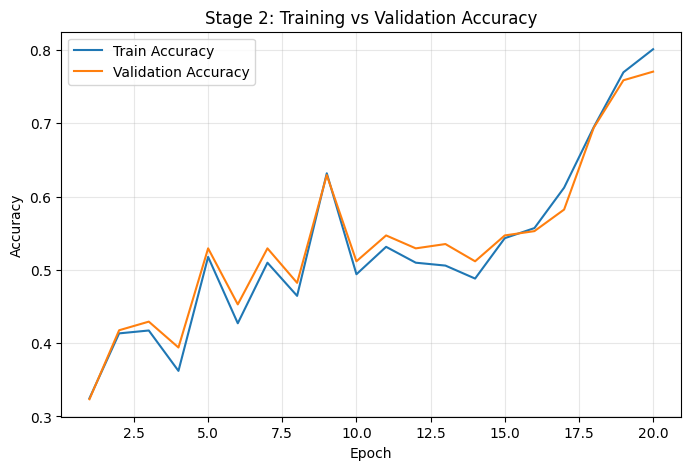

In [82]:
best_sport_epoch = int(np.argmax(sport_val_acc_history))
best_sport_val_acc = sport_val_acc_history[best_sport_epoch]

print(f'Best stage 2 validation accuracy: {best_sport_val_acc:.4f} at epoch {best_sport_epoch + 1}')

plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), sport_train_acc_history, label='Train Accuracy')
plt.plot(range(1, EPOCHS + 1), sport_val_acc_history, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Stage 2: Training vs Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Stage 2 Test Accuracy        : 0.7412
Stage 2 Test Precision Macro : 0.5313
Stage 2 Test Recall Macro    : 0.4868
Stage 2 Test F1-score Macro  : 0.4923
Stage 2 Test Precision Weight: 0.6870
Stage 2 Test Recall Weight   : 0.7412
Stage 2 Test F1-score Weight : 0.6894

Detailed classification report:
              precision    recall  f1-score   support

   athletics       0.00      0.00      0.00        10
      boxing       1.00      0.57      0.73        14
     cricket       0.97      0.90      0.94        42
     cycling       0.00      0.00      0.00         6
    football       0.59      1.00      0.74        55
    formula1       0.94      0.89      0.91        18
        golf       0.00      0.00      0.00         8
      tennis       0.75      0.53      0.62        17

    accuracy                           0.74       170
   macro avg       0.53      0.49      0.49       170
weighted avg       0.69      0.74      0.69       170



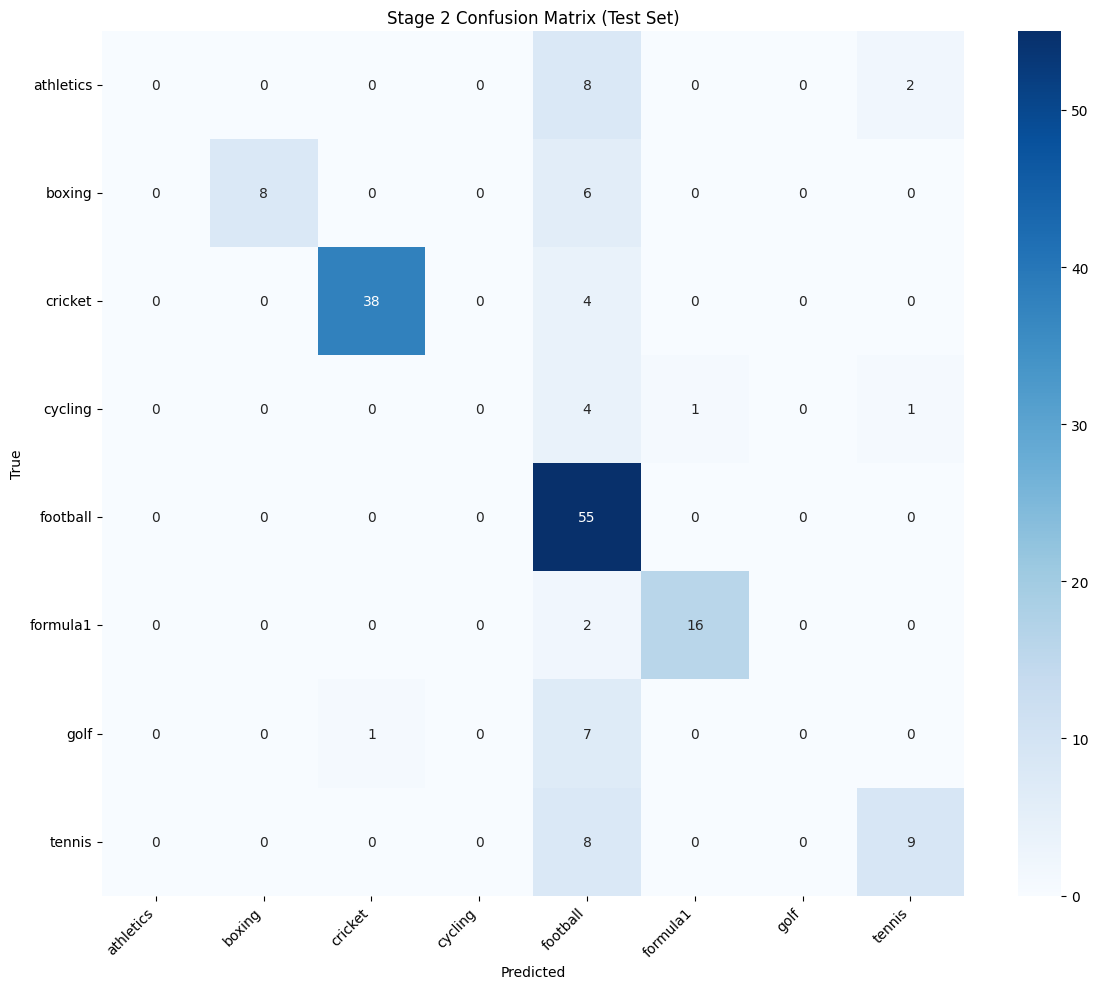

In [83]:
y_test_sport_pred = sport_mlp.predict(X_test_sport_vec)

test_acc = accuracy_score(y_test_sport, y_test_sport_pred)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test_sport,
    y_test_sport_pred,
    average='macro',
    zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_test_sport,
    y_test_sport_pred,
    average='weighted',
    zero_division=0
)

print(f'Stage 2 Test Accuracy        : {test_acc:.4f}')
print(f'Stage 2 Test Precision Macro : {precision_macro:.4f}')
print(f'Stage 2 Test Recall Macro    : {recall_macro:.4f}')
print(f'Stage 2 Test F1-score Macro  : {f1_macro:.4f}')
print(f'Stage 2 Test Precision Weight: {precision_weighted:.4f}')
print(f'Stage 2 Test Recall Weight   : {recall_weighted:.4f}')
print(f'Stage 2 Test F1-score Weight : {f1_weighted:.4f}')

labels_in_test = sorted(y_test_sport.unique())
target_names_in_test = [sport_id_to_label[label] for label in labels_in_test]

print('\nDetailed classification report:')
print(
    classification_report(
        y_test_sport,
        y_test_sport_pred,
        labels=labels_in_test,
        target_names=target_names_in_test,
        zero_division=0
    )
)

cm = confusion_matrix(y_test_sport, y_test_sport_pred, labels=labels_in_test)
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names_in_test,
    yticklabels=target_names_in_test
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Stage 2 Confusion Matrix (Test Set)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. End-to-End Pipeline Evaluation

In [84]:
def predict_pipeline(texts):
    if VECTORIZER_TYPE == 'TF-IDF':
        binary_features = binary_vectorizer.transform(texts)
    else:
        binary_features = _docs_to_matrix_pretrained(texts, ft_model, W2V_VECTOR_SIZE)

    binary_preds = binary_mlp.predict(binary_features)

    final_preds = []
    for text, binary_pred in zip(texts, binary_preds):
        if binary_pred == 0:
            final_preds.append('non-sport')
        else:
            if SPORT_VECTORIZER_TYPE == 'TF-IDF':
                sport_features = sport_vectorizer.transform([text])
            else:  # fastText pretrained (300d)
                sport_features = _docs_to_matrix_pretrained([text], ft_model, W2V_VECTOR_SIZE)

            sport_pred = sport_mlp.predict(sport_features)[0]
            final_preds.append(sport_id_to_label[sport_pred])

    return final_preds, binary_preds


print("=============================================================")
print(f'[{SPORT_VECTORIZER_TYPE}]')
pipeline_test_preds, binary_test_preds = predict_pipeline(test_df['combined_text'])
pipeline_test_true = test_df['final_label'].tolist()

pipeline_acc = accuracy_score(pipeline_test_true, pipeline_test_preds)
pipeline_precision_macro, pipeline_recall_macro, pipeline_f1_macro, _ = precision_recall_fscore_support(
    pipeline_test_true,
    pipeline_test_preds,
    average='macro',
    zero_division=0
)
pipeline_precision_weighted, pipeline_recall_weighted, pipeline_f1_weighted, _ = precision_recall_fscore_support(
    pipeline_test_true,
    pipeline_test_preds,
    average='weighted',
    zero_division=0
)

print(f'Pipeline Test Accuracy        : {pipeline_acc:.4f}')
print(f'Pipeline Test Precision Macro : {pipeline_precision_macro:.4f}')
print(f'Pipeline Test Recall Macro    : {pipeline_recall_macro:.4f}')
print(f'Pipeline Test F1-score Macro  : {pipeline_f1_macro:.4f}')
print(f'Pipeline Test Precision Weight: {pipeline_precision_weighted:.4f}')
print(f'Pipeline Test Recall Weight   : {pipeline_recall_weighted:.4f}')
print(f'Pipeline Test F1-score Weight : {pipeline_f1_weighted:.4f}')

pipeline_labels = ['non-sport'] + sport_class_names
print('\nDetailed pipeline classification report:')
print(classification_report(pipeline_test_true, pipeline_test_preds, labels=pipeline_labels, zero_division=0))


[fastText pretrained (300d)]


ValueError: X has 300 features, but MLPClassifier is expecting 900 features as input.

## 8. Try New Examples

In [ ]:
new_samples = [
    'Manchester United won 3-1 with a late goal in the Premier League.',
    'The batter scored a century after a dominant opening partnership in the second innings.',
    'The driver secured pole position and managed tyre wear perfectly over the final laps.',
    'She broke serve twice to win the second set and reach the quarter-final.',
    'Donald Trump just died in his house in Florida.',
    'Bankrupt company announces restructuring plan for next quarter.'
]

pipeline_preds, stage1_preds = predict_pipeline(new_samples)
stage1_probs = binary_mlp.predict_proba(binary_vectorizer.transform(new_samples))[:, 1]

for text, stage1_pred, stage1_prob, final_pred in zip(new_samples, stage1_preds, stage1_probs, pipeline_preds):
    stage1_label = 'sport' if stage1_pred == 1 else 'non-sport'
    print(f'Text: {text}')
    print(f'Stage 1 prediction: {stage1_label} (sport probability={stage1_prob:.3f})')
    print(f'Final pipeline label: {final_pred}')
    print('-' * 80)


ValueError: X has 30000 features, but MLPClassifier is expecting 300 features as input.